### **Imports and other prerequisites**
Importing necessary libraries, modules, and the Bates-Hawkes stationary proxy class.

In [1]:
import json
import os
import warnings
warnings.filterwarnings('ignore')
import math
from math import erf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import Rbf
from BnS import BnS
from BatesHawkes import BatesHawkes

### **Initial configuration, Data recovery and validation**
Linking data files, setting up config parameters, and ensuring necessary datasets (including pre-calculated Vega) are available in memory.

In [2]:
DIVIDEND_YIELD = 0.0 # Assuming q=0 for GLD (Gold ETF)

# --- SAFETY CHECK: Restore variables from disk if missing from memory ---
if 'S0' not in globals():
    META_JSON_PATH = "Data/gld_chain_wide_meta.json"
    with open(META_JSON_PATH, "r", encoding="utf-8") as f:
        meta = json.load(f)
        for k in ["S0", "spot", "spot_price", "underlying_price", "underlying_last"]:
            if k in meta:
                S0 = float(meta[k])
                break
    print(f"[RECOVERY] Spot price (S0) restored from JSON: {S0:.2f}")

if 'dataset_chebyshev' not in globals():
    OUTPUT_CHEB_PATH = "Data/gld_iv_dataset_chebyshev.csv"
    if os.path.exists(OUTPUT_CHEB_PATH):
        dataset_chebyshev = pd.read_csv(OUTPUT_CHEB_PATH)
        print(f"[RECOVERY] 'dataset_chebyshev' loaded from disk: {len(dataset_chebyshev)} rows.")
    else:
        raise FileNotFoundError(f"Cannot find {OUTPUT_CHEB_PATH}. Please run the sampling cell in the previous notebook first.")

# Verify that Vega is present in the dataset
if 'vega' not in dataset_chebyshev.columns:
    print("[INFO] Calculating Black-Scholes Vega for the dataset...")
    dataset_chebyshev['vega'] = dataset_chebyshev.apply(
        lambda row: BnS.calculate_bs_vega(
            S=S0, 
            K=row['K'], 
            T=row['T'], 
            r=row['rate'], 
            q=DIVIDEND_YIELD, 
            sigma=row['implied_vol']
        ), 
        axis=1
    )
    print("[SUCCESS] 'vega' column added!")

display(dataset_chebyshev.head())

[RECOVERY] Spot price (S0) restored from JSON: 437.82
[RECOVERY] 'dataset_chebyshev' loaded from disk: 64 rows.
[INFO] Calculating Black-Scholes Vega for the dataset...
[SUCCESS] 'vega' column added!


,expiry,T,K,price,rate,implied_vol,vega
0,2026-06-30,0.242596,358.0,87.52,0.037163,0.371853,39.893144
1,2026-06-30,0.242596,375.0,72.74,0.037163,0.354184,50.784943
2,2026-06-30,0.242596,395.0,56.57,0.037163,0.336587,64.543165
3,2026-06-30,0.242596,425.0,35.85,0.037163,0.316880,81.571765
4,2026-06-30,0.242596,455.0,20.77,0.037163,0.307369,85.422635


### **Bates-Hawkes Model Calibration and Vega-Weighting**
In this section, we extend the jump-diffusion framework by introducing a proxy for the Hawkes process (self-exciting jumps). A full event-dependent Hawkes pricing engine is computationally prohibitive for surface calibration. Therefore, we implement a stationary-intensity proxy.

We map the Hawkes process to its long-run mean effective intensity: $\lambda_{eff} = \lambda_0 / (1 - \alpha / \beta)$. 
This allows us to use the same dataset, Vega-weighted objective function, and SLSQP workflow to estimate the baseline arrival rate ($\lambda_0$), the excitation size ($\alpha$), and the decay speed ($\beta$) while keeping the model mathematically tractable. 

We expand the parameter space to 10 variables, utilizing mild regularization in the cost function to keep the proxy away from critical (explosive) branching regimes ($\alpha \approx \beta$).

In [3]:
### **Model calibration execution**
# Running the optimization algorithms to find the best-fitting Bates-Hawkes proxy parameters.

optimal_params_bh = BatesHawkes.calibrate_bates_hawkes_proxy(dataset_chebyshev, S0, q=DIVIDEND_YIELD)

[INFO] Starting Global Calibration for Bates-Hawkes proxy...
differential_evolution step 1: f(x)= 0.004105222154426364
differential_evolution step 2: f(x)= 0.0026203867790381757
differential_evolution step 3: f(x)= 0.0025493678325499763
differential_evolution step 4: f(x)= 0.0017337133799280344
differential_evolution step 5: f(x)= 0.0008186141694814591
differential_evolution step 6: f(x)= 0.0008186141694814591
differential_evolution step 7: f(x)= 0.0008186141694814591
differential_evolution step 8: f(x)= 0.0007124868728700165
differential_evolution step 9: f(x)= 0.0007124868728700165
differential_evolution step 10: f(x)= 0.0005715977567641592
differential_evolution step 11: f(x)= 0.00014599763245023523
differential_evolution step 12: f(x)= 0.00014599763245023523
differential_evolution step 13: f(x)= 0.00014599763245023523
differential_evolution step 14: f(x)= 0.00014599763245023523
differential_evolution step 15: f(x)= 0.00014599763245023523
differential_evolution step 16: f(x)= 0.0001

### **Visualizations**
Generating Volatility Smile grids to compare Market IV against the theoretical Bates-Hawkes Proxy Model IV across different maturities.

[INFO] Generating Volatility Smile grid for Bates-Hawkes Proxy Model...


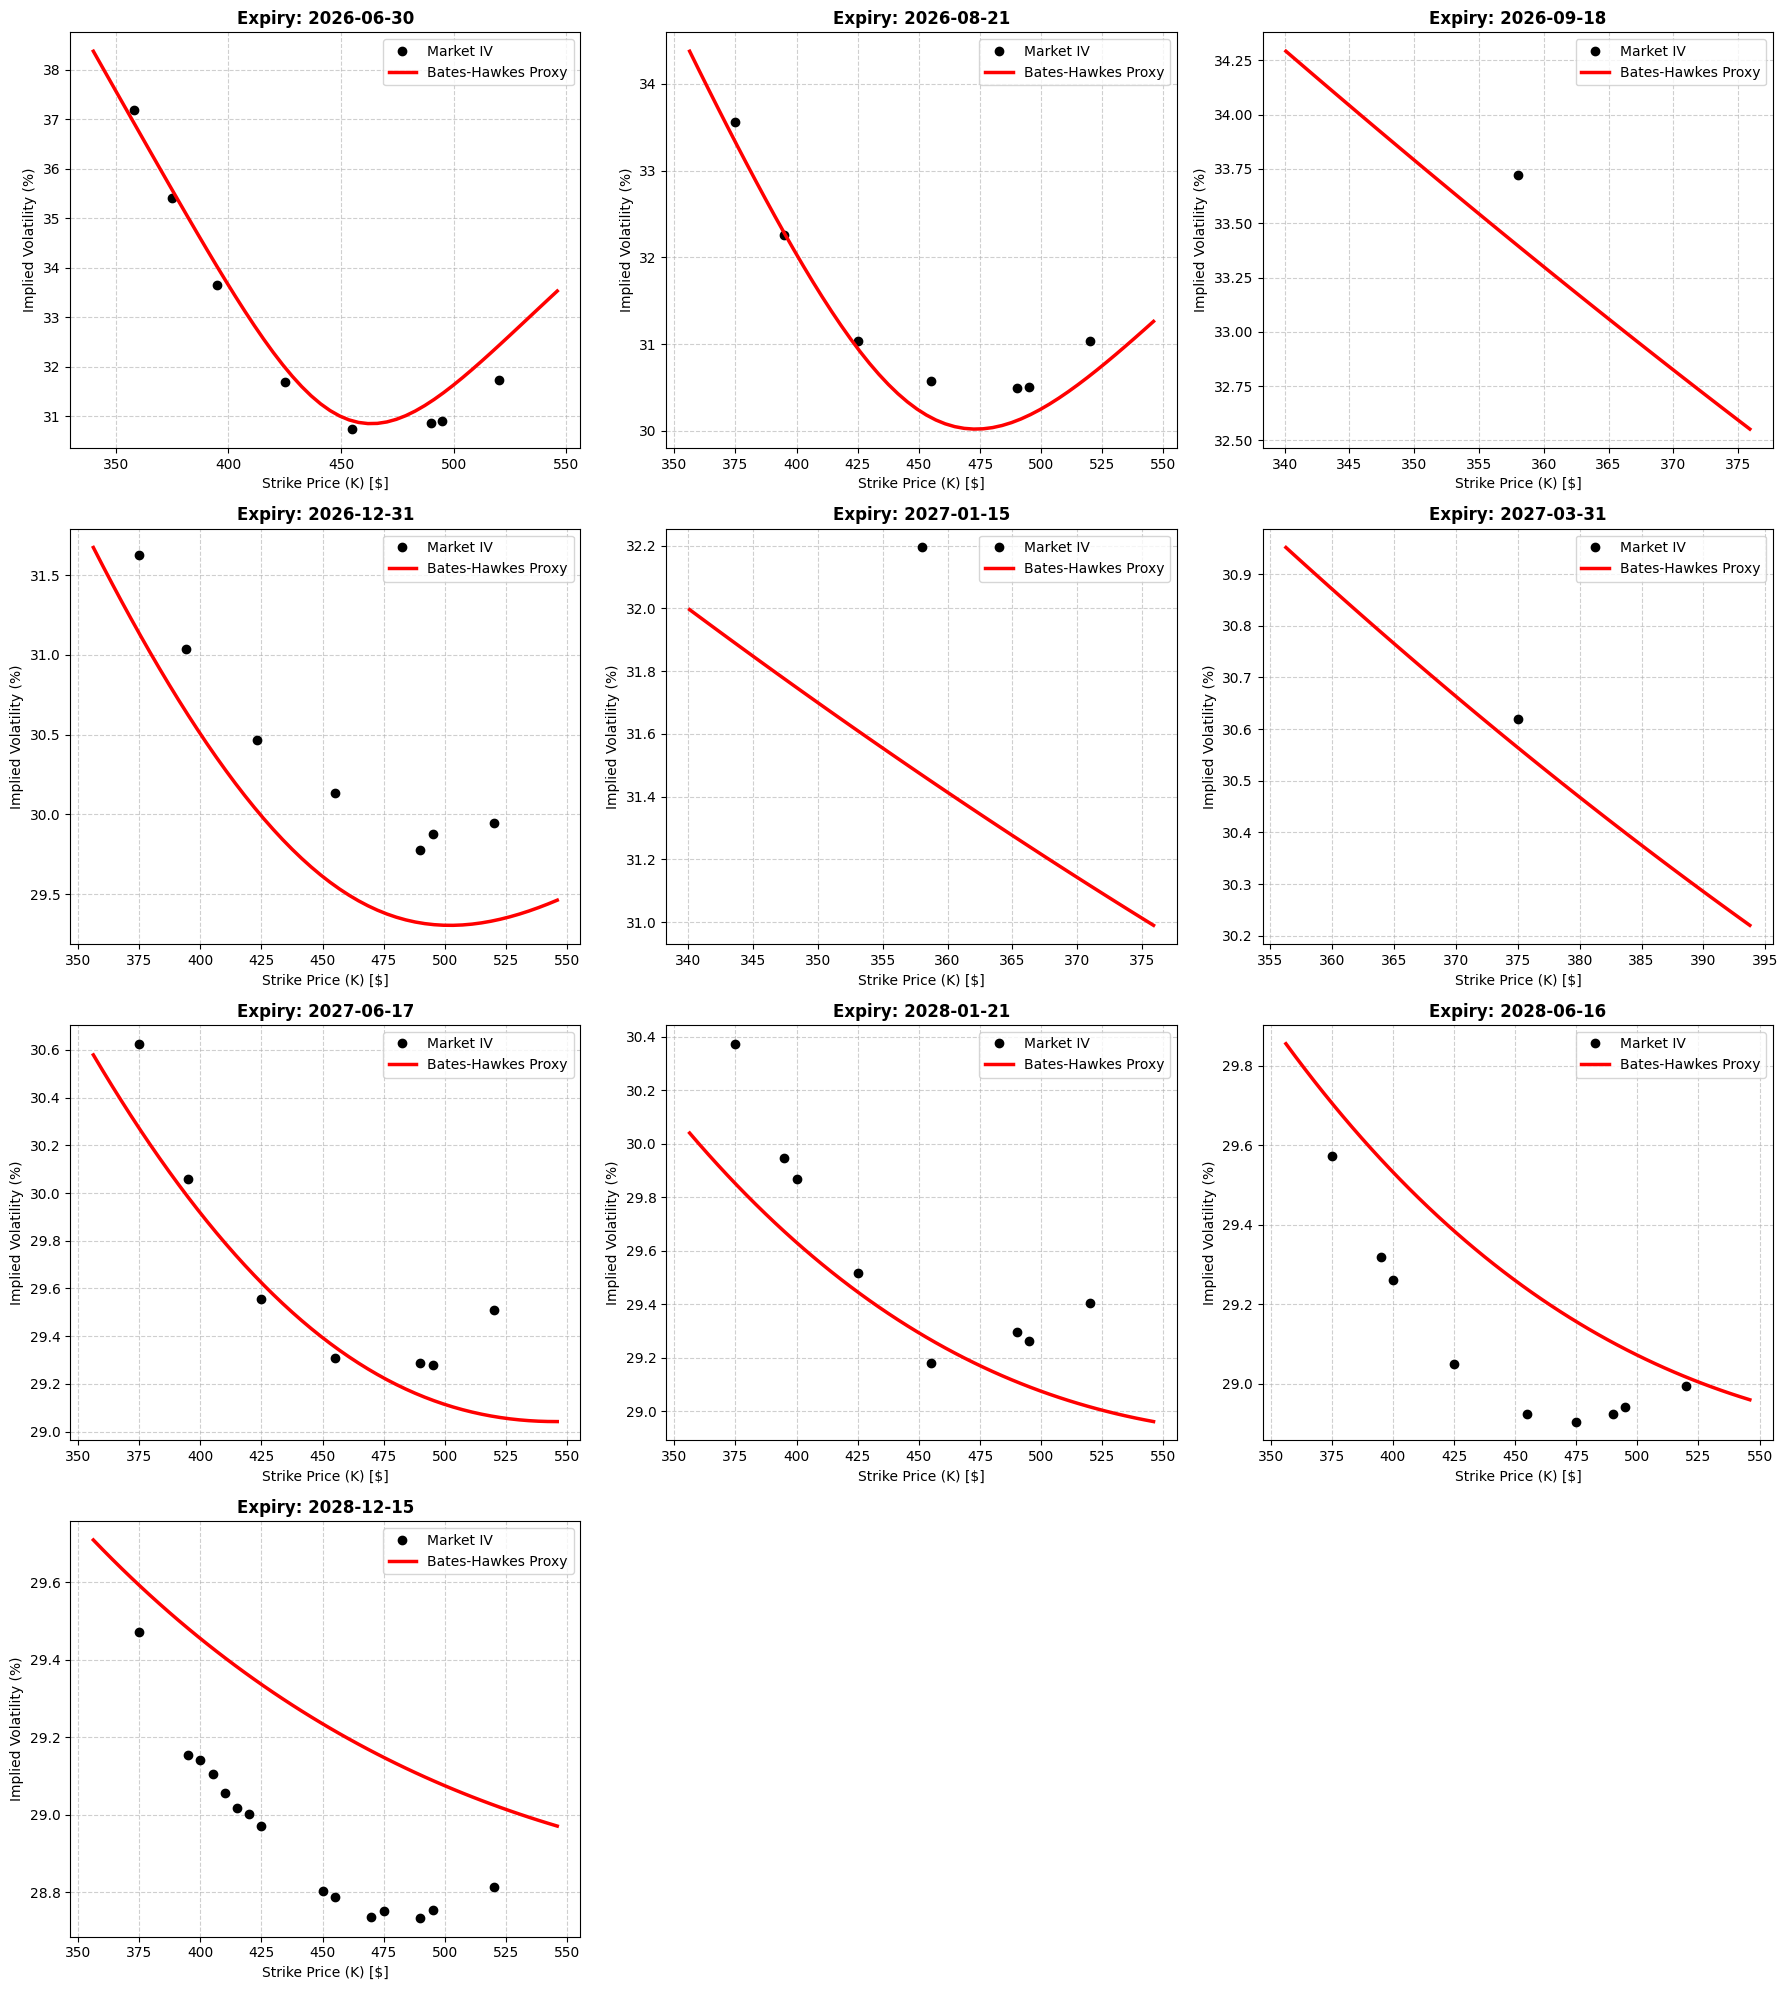

In [4]:
print("[INFO] Generating Volatility Smile grid for Bates-Hawkes Proxy Model...")

# Unpack your 10 optimized parameters
v0, kappa, theta, sigma, rho, lambda0, alpha, beta, mu_J, sigma_J = optimal_params_bh

maturities = sorted(dataset_chebyshev['T'].unique())

# --- OPTIONAL: EXCLUDE MATURITIES ---
exclude_maturities = [] 
maturities = [m for m in maturities if m not in exclude_maturities]
num_maturities = len(maturities)

# --- GRID CALCULATION ---
cols = min(3, num_maturities)
rows = math.ceil(num_maturities / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

if num_maturities == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()

for i, T in enumerate(maturities):
    ax = axes[i]
    df_T = dataset_chebyshev[dataset_chebyshev['T'] == T]
    
    # Plot Market IV
    ax.plot(df_T['K'], df_T['implied_vol'] * 100, 'ko', markersize=6, label='Market IV')
    
    # Generate smooth theoretical Bates-Hawkes Curve
    K_min, K_max = df_T['K'].min(), df_T['K'].max()
    K_grid = np.linspace(K_min * 0.95, K_max * 1.05, 50)
    
    r = df_T['rate'].iloc[0] 
    q = DIVIDEND_YIELD
    
    bh_iv_curve = []
    
    for K in K_grid:
        # Calculate Theoretical Price using the proxy fast pricer
        bh_price = BatesHawkes.price_proxy_fast(
            S0, K, T, v0, kappa, theta, sigma, rho, lambda0, alpha, beta, mu_J, sigma_J, r, q
        )
        
        # Convert Price back to IV
        bh_iv = BnS.implied_vol_call(price=bh_price, S=S0, K=K, T=T, r=r, q=q)
        
        if np.isnan(bh_iv) or bh_iv <= 0:
            bh_iv_curve.append(np.nan)
        else:
            bh_iv_curve.append(bh_iv * 100)
            
    # Plot Bates-Hawkes Model IV
    ax.plot(K_grid, bh_iv_curve, 'r-', linewidth=2.5, label='Bates-Hawkes Proxy')
    
    # Formatting
    expiry_date = df_T['expiry'].iloc[0] if 'expiry' in df_T.columns else f"T={T:.2f}"
    ax.set_title(f'Expiry: {expiry_date}', fontweight='bold')
    ax.set_xlabel('Strike Price (K) [$]')
    ax.set_ylabel('Implied Volatility (%)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("Data/bates_hawkes_volatility_smile.png", dpi=300)
plt.show()

### **Residual Heatmap (Market vs. Bates-Hawkes Proxy)**
In this section, we analyze the residuals of the Bates-Hawkes Proxy Model. 
By projecting the difference between the Market IV and the Model IV onto a Scatter-Heatmap (Time to Maturity vs. Moneyness), we can verify the fit across the surface. Note that since this is a stationary proxy using an effective mean intensity ($\lambda_{eff}$), the residuals should closely mirror those of the standard Bates model, serving primarily as a validation of the estimated branching ratio dynamics.

[INFO] Calculating Bates-Hawkes theoretical Implied Volatilities for residuals...
[INFO] Heatmap generation completed on 64 valid points...


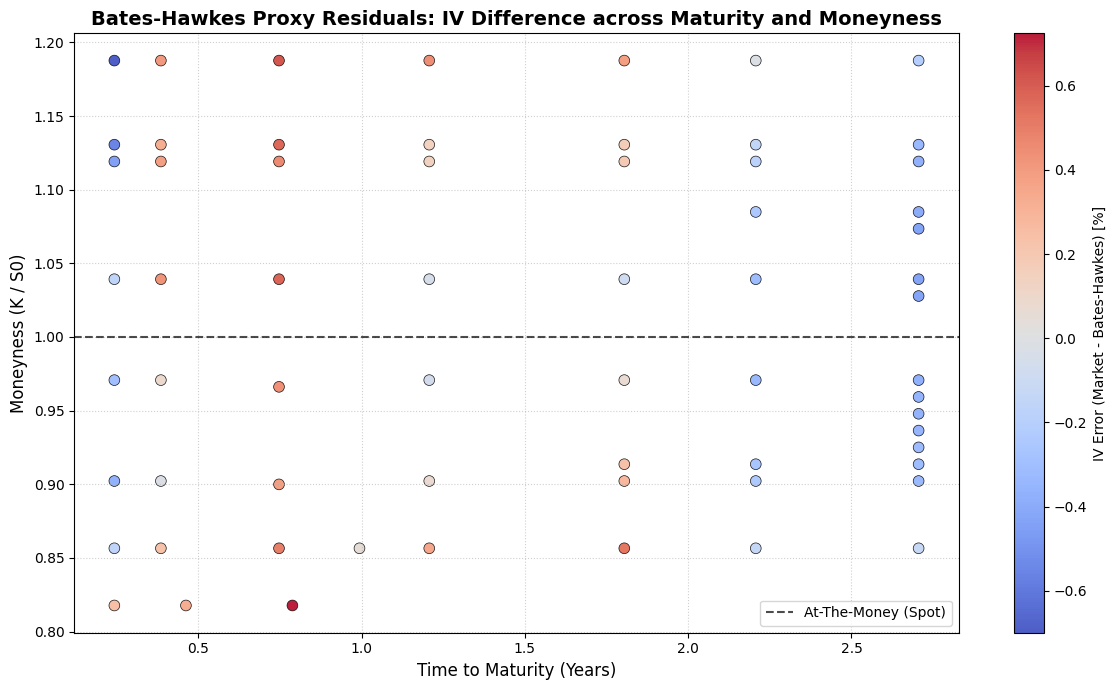

In [5]:
print("[INFO] Calculating Bates-Hawkes theoretical Implied Volatilities for residuals...")

v0, kappa, theta, sigma, rho, lambda0, alpha, beta, mu_J, sigma_J = optimal_params_bh
q = DIVIDEND_YIELD 

residuals_list = []

for _, row in dataset_chebyshev.iterrows():
    K = row['K']
    T = row['T']
    r = row['rate']
    market_iv = row['implied_vol']
    
    bh_price = BatesHawkes.price_proxy_fast(
        S0, K, T, v0, kappa, theta, sigma, rho, lambda0, alpha, beta, mu_J, sigma_J, r, q
    )
    bh_iv = BnS.implied_vol_call(price=bh_price, S=S0, K=K, T=T, r=r, q=q)
    
    if not np.isnan(bh_iv) and bh_iv > 0:
        moneyness = K / S0
        iv_residual = (market_iv - bh_iv) * 100 
        residuals_list.append({
            'T': T, 
            'moneyness': moneyness, 
            'iv_residual': iv_residual
        })

df_residuals = pd.DataFrame(residuals_list)
print(f"[INFO] Heatmap generation completed on {len(df_residuals)} valid points...")

# --- CHART CREATION ---
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    df_residuals['T'], 
    df_residuals['moneyness'], 
    c=df_residuals['iv_residual'], 
    cmap='coolwarm', 
    s=60, 
    edgecolors='k', 
    linewidth=0.5,
    alpha=0.9
)

plt.colorbar(scatter, label='IV Error (Market - Bates-Hawkes) [%]')
plt.axhline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='At-The-Money (Spot)')

plt.title('Bates-Hawkes Proxy Residuals: IV Difference across Maturity and Moneyness', fontsize=14, fontweight='bold')
plt.xlabel('Time to Maturity (Years)', fontsize=12)
plt.ylabel('Moneyness (K / S0)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("Data/bates_hawkes_residual_heatmap.png", dpi=300)
plt.show()